<div style="background-color:#1F3864; color:white; padding:20px; border-radius:8px;">
<h1 style="margin:0; color:white;"><b>Caso de Estudio: Evaluación de Modelos de Clasificación y Regresión</b></h1>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>BIY7121 — Minería de Datos | DuocUC, Escuela de Informática y Telecomunicaciones</b></h3>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>Operaciones de aeronaves en aeropuertos chilenos</b></h3>
</div>

---

**Nivel cognitivo (Bloom):** Niveles 3 y 4 — Aplicación y Análisis  
**Marco metodológico:** CRISP-DM (Chapman et al., 2000)  

---

| Integrante | Rol |
|------------|-----|
| Benjamin Herrera | Estudiante |

**Dataset:** `operaciones-aeropuertos.csv` — Operaciones aéreas mensuales de 69 aeropuertos chilenos.

**Variable objetivo (clasificación):** `internacional_domestico` (I/D)  
**Variable objetivo (regresión):** `cnt_operaciones`  

**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

---


---

## 📖 Glosario para Lectores No Técnicos

| Término | Significado Simple |
|---------|-------------------|
| **Dataset** | Archivo con datos (como una hoja de Excel) |
| **Feature / Variable** | Una columna en los datos, como "mes" o "aeropuerto" |
| **Modelo** | Una fórmula matemática que hace predicciones |
| **Entrenar** | Enseñar al modelo con datos históricos |
| **Test / Prueba** | Verificar que el modelo funciona con datos nuevos |
| **Accuracy** | De 100 predicciones, cuántas fueron correctas |
| **Precision** | De las veces que dijimos "internacional", cuántas realmente lo eran |
| **Recall** | De las veces que realmente era internacional, cuántas predijimos |
| **F1-Score** | Balance entre precisión y recall |
| **MAE** | Error promedio absoluto de las predicciones |
| **RMSE** | Error cuadrático medio (penaliza más los errores grandes) |
| **Overfitting** | Cuando el modelo memoriza en lugar de aprender realmente |
| **R²** | Qué porcentaje de la variabilidad explicamos con el modelo |

### ¿Cómo funciona cada modelo? (Analogías simples)

- **Regresión Logística**: Como un semáforo: según ciertas condiciones, decide si es verde (I) o rojo (D)
- **Regresión Lineal**: Como una recta que intenta pasar lo más cerca posible de todos los puntos

---


## Objetivos de aprendizaje

1. **Aplicar** las métricas de evaluación apropiadas para modelos de clasificación y de regresión (Bloom 3).
2. **Analizar** por qué una métrica puede ser engañosa según el contexto y **seleccionar** la adecuada (Bloom 4).
3. **Derivar variables predictoras** justificadas en función del objetivo de negocio, dentro del marco CRISP-DM.

---


## **Índice**

1. [Fase 1: Entendimiento del Negocio](#1-fase-1-entendimiento-del-negocio)
2. [Fase 2: Entendimiento de los Datos](#2-fase-2-entendimiento-de-los-datos)
3. [Fase 3: Preparación de los Datos](#3-fase-3-preparacion-de-los-datos)
4. [Fase 4: Modelado (Clasificación)](#4-fase-4-modelado-clasificacion)
5. [Fase 5: Evaluación (Clasificación)](#5-fase-5-evaluacion-clasificacion)
6. [Fase 5: Modelado y Evaluación (Regresión)](#6-fase-5-modelado-y-evaluacion-regresion)
7. [Preguntas del Caso](#7-preguntas-del-caso)
8. [Referencias](#8-referencias)

---


## **1. Fase 1: Entendimiento del Negocio**

<span style="color:#2E75B6;">**Contexto del negocio:**</span> La autoridad aeronáutica chilena (DGAC / JAC) necesita apoyar dos decisiones operativas con minería de datos:

1. **Clasificar** si un registro de operaciones corresponde a tráfico **internacional (I)** o **doméstico (D)**, para dimensionar control fronterizo, *slots* y personal especializado.
2. **Estimar** la **cantidad de operaciones** (`cnt_operaciones`) de un aeropuerto en un mes, para planificar infraestructura y turnos.

<span style="color:#2E75B6;">**Objetivos clave del proyecto:**</span>

| Objetivo | Descripción |
|----------|-------------|
| OBJ-1 | Clasificar correctamente el tipo de tráfico (I/D) con precisión ≥ 0.80 |
| OBJ-2 | Estimar el volumen mensual de operaciones con un error aceptable (RMSE < 500) |
| OBJ-3 | Identificar las variables más relevantes para la predicción |

<span style="color:#2E75B6;">**Pregunta analítica:**</span> ¿Puede un clasificador de Regresión Logística predecir correctamente si una operación es internacional o doméstica, alcanzando una precisión ≥ 0.80? ¿Puede un modelo de Regresión Lineal estimar el volumen de operaciones con RMSE < 500?

<span style="color:#2E75B6;">**Justificación del método:**</span>

- **Regresión Logística:** Adecuada para clasificación binaria, entrega probabilidades interpretables, rápida de entrenar y funciona bien con features numéricas.
- **Regresión Lineal:** Modelo simple e interpretable para regresión, permite entender el impacto de cada variable en el volumen de operaciones.

---


## **2. Fase 2: Entendimiento de los Datos**

<span style="color:#2E75B6;">**2.1 Descripción del dataset:**</span> El dataset `operaciones-aeropuertos.csv` contiene registros mensuales de operaciones aéreas de 69 aeropuertos chilenos (códigos OACI), desde enero de 2000 hasta marzo de 2026. Las columnas disponibles son: `mes_id` (formato AAAAMM), `aeropuerto_oaci`, `internacional_domestico` (I/D) y `cnt_operaciones`.

**Fuente:** Portal de Datos Abiertos del Estado de Chile (datos.gob.cl, Ministerio de Hacienda), a partir de información de la autoridad aeronáutica (DGAC/JAC).


In [1]:
# --- Imports estándar de Minería de Datos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# --- Configuración institucional ---
SEMILLA = 42
COLOR_TITULO    = "#1F3864"
COLOR_DESTACADO = "#2E75B6"

np.random.seed(SEMILLA)
pd.options.display.float_format = "{:,.4f}".format

print("Entorno preparado correctamente. Semilla fijada en", SEMILLA)


Entorno preparado correctamente. Semilla fijada en 42


In [2]:
# --- Carga del dataset de operaciones aeroportuarias ---
df = pd.read_csv("operaciones-aeropuertos.csv")

print("Dimensiones del dataset:", df.shape)
print()
print("Primeras filas:")
df.head()


Dimensiones del dataset: (15846, 4)

Primeras filas:


,mes_id,aeropuerto_oaci,internacional_domestico,cnt_operaciones
0,200001,SCAP,D,6
1,200001,SCAR,D,691
2,200001,SCAR,I,139
3,200001,SCBA,D,382
4,200001,SCCC,D,82


<span style="color:#2E75B6;">**2.2 Análisis exploratorio:**</span> A continuación se exploran los tipos de datos, valores nulos, distribución de clases y estadísticas descriptivas.


In [3]:
# TODO 1: exploración de datos
print("=== Tipos de datos ===")
print(df.dtypes)
print()

print("=== Valores nulos ===")
print(df.isna().sum())
print()

print("=== Distribución de la clase internacional_domestico ===")
print(df["internacional_domestico"].value_counts())
print(df["internacional_domestico"].value_counts(normalize=True))
print()

print("=== Resumen estadístico de cnt_operaciones ===")
print(df["cnt_operaciones"].describe())


=== Tipos de datos ===
mes_id                     int64
aeropuerto_oaci              str
internacional_domestico      str
cnt_operaciones            int64
dtype: object

=== Valores nulos ===
mes_id                     0
aeropuerto_oaci            0
internacional_domestico    0
cnt_operaciones            0
dtype: int64

=== Distribución de la clase internacional_domestico ===
internacional_domestico
D    11884
I     3962
Name: count, dtype: int64
internacional_domestico
D   0.7500
I   0.2500
Name: proportion, dtype: float64

=== Resumen estadístico de cnt_operaciones ===
count   15,846.0000
mean       659.0223
std      1,207.2874
min          1.0000
25%         24.0000
50%        172.0000
75%        781.0000
max     10,722.0000
Name: cnt_operaciones, dtype: float64


<span style="color:#2E75B6;">**Análisis de los datos:**</span>

- **Tipos de datos:** Contamos con 2 columnas numéricas (`mes_id`, `cnt_operaciones`) y 2 categóricas (`aeropuerto_oaci`, `internacional_domestico`). No hay valores nulos en el dataset.
- **Balance de clases:** La clase `D` (doméstico) representa el **75%** de los registros, mientras que `I` (internacional) solo el **25%**. Esto es un desbalance importante que puede afectar la exactitud como métrica.
- **Distribución del volumen:** `cnt_operaciones` tiene una mediana de 172 y una media de 659, con valores extremos de hasta 10,722 operaciones. La distribución está fuertemente sesgada a la derecha (presencia de aeropuertos muy grandes como SCEL/Santiago).


<span style="color:#2E75B6;">**2.3 Visualización de la distribución:**</span> Histogramas para visualizar la distribución de las variables numéricas y el balance de clases.


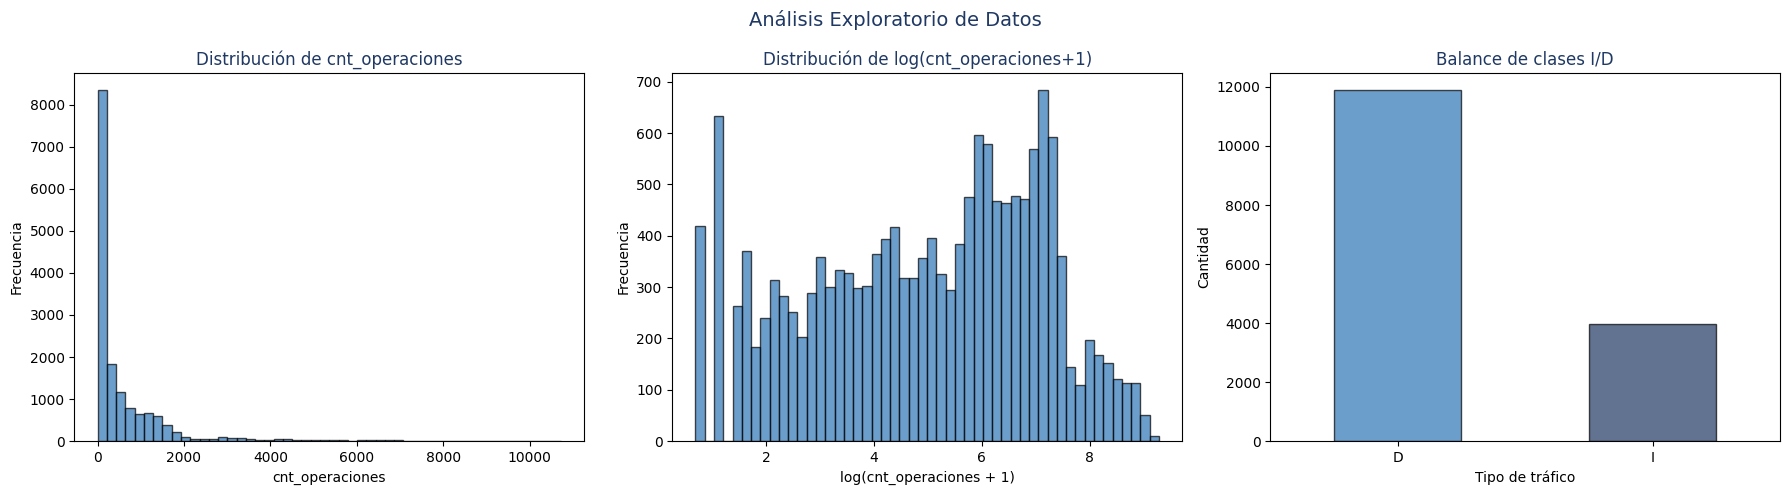

In [4]:
# --- Gráfico de distribución de cnt_operaciones ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de cnt_operaciones
axes[0].hist(df["cnt_operaciones"], bins=50, edgecolor="black", alpha=0.7, color="#2E75B6")
axes[0].set_title("Distribución de cnt_operaciones", fontsize=12, color=COLOR_TITULO)
axes[0].set_xlabel("cnt_operaciones")
axes[0].set_ylabel("Frecuencia")

# Histograma de cnt_operaciones (log)
axes[1].hist(np.log1p(df["cnt_operaciones"]), bins=50, edgecolor="black", alpha=0.7, color="#2E75B6")
axes[1].set_title("Distribución de log(cnt_operaciones+1)", fontsize=12, color=COLOR_TITULO)
axes[1].set_xlabel("log(cnt_operaciones + 1)")
axes[1].set_ylabel("Frecuencia")

# Barras de clase I/D
df["internacional_domestico"].value_counts().plot(kind="bar", ax=axes[2], color=["#2E75B6", "#1F3864"], edgecolor="black", alpha=0.7)
axes[2].set_title("Balance de clases I/D", fontsize=12, color=COLOR_TITULO)
axes[2].set_xlabel("Tipo de tráfico")
axes[2].set_ylabel("Cantidad")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Análisis Exploratorio de Datos", fontsize=14, color=COLOR_TITULO)
plt.tight_layout()
plt.show()


## **3. Fase 3: Preparación de los Datos**

<span style="color:#2E75B6;">**3.1 Derivación de variables predictoras:**</span> Se crean las siguientes variables a partir de los datos originales:

| Variable | Descripción | Justificación |
|----------|-------------|---------------|
| `anio` | Año extraído de `mes_id` (`mes_id // 100`) | Captura tendencias temporales y crecimiento del tráfico aéreo |
| `mes` | Mes extraído de `mes_id` (`mes_id % 100`) | Captura estacionalidad (temporada alta/baja) |
| `log_ops` | `log(1 + cnt_operaciones)` | Normaliza la distribución sesgada de `cnt_operaciones` |
| `es_internacional` | 1 si I, 0 si D | Variable objetivo para clasificación, predictora para regresión |


In [5]:
# TODO 2: crear variables predictoras
df["anio"] = df["mes_id"] // 100
df["mes"] = df["mes_id"] % 100
df["log_ops"] = np.log1p(df["cnt_operaciones"])
df["es_internacional"] = (df["internacional_domestico"] == "I").astype(int)

print("Variables creadas exitosamente.")
print()
print(df[["anio", "mes", "log_ops", "es_internacional"]].head())


Variables creadas exitosamente.

   anio  mes  log_ops  es_internacional
0  2000    1   1.9459                 0
1  2000    1   6.5396                 0
2  2000    1   4.9416                 1
3  2000    1   5.9480                 0
4  2000    1   4.4188                 0


<span style="color:#2E75B6;">**Justificación de variables:**</span>

- **`anio`** y **`mes`**: El tráfico aéreo tiene un componente temporal importante. El año captura el crecimiento sostenido del sector (más vuelos cada año) y efectos de larga duración (como la recuperación post-pandemia). El mes captura la estacionalidad: temporada alta en enero/febrero (verano austral) y baja en junio/julio (invierno).
- **`log_ops`**: La distribución de `cnt_operaciones` está fuertemente sesgada a la derecha. La transformación logarítmica la hace más simétrica y mejora el rendimiento de modelos lineales.
- **`es_internacional`**: El tipo de tráfico es un predictor clave del volumen de operaciones. Los vuelos internacionales suelen ser menos frecuentes pero de mayor escala que los domésticos.


## **4. Fase 4: Modelado — Clasificación**

<span style="color:#2E75B6;">**4.1 Clasificador I/D:**</span> Se entrena un modelo de **Regresión Logística** para predecir si una operación es internacional o doméstica. Se utiliza partición 80/20 estratificada para mantener la proporción de clases.

**Features:** `anio`, `mes`, `cnt_operaciones`, `log_ops`  
**Target:** `es_internacional`


In [6]:
# TODO 3: clasificador I/D
# 1) Definir X e y
X_clf = df[["anio", "mes", "cnt_operaciones", "log_ops"]]
y_clf = df["es_internacional"]

# 2) Dividir 80/20 estratificado
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEMILLA, stratify=y_clf
)

print("Partición estratificada 80/20:")
print(f"  Train: {X_train_clf.shape[0]} ({X_train_clf.shape[0]/len(df)*100:.1f}%)")
print(f"  Test:  {X_test_clf.shape[0]} ({X_test_clf.shape[0]/len(df)*100:.1f}%)")
print()

# 3) Escalar (fit SOLO en train)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# 4) Entrenar Regresión Logística
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEMILLA)
clf.fit(X_train_clf_scaled, y_train_clf)

# 5) Predecir
y_pred_clf = clf.predict(X_test_clf_scaled)
y_proba_clf = clf.predict_proba(X_test_clf_scaled)[:, 1]

print("Modelo de clasificación entrenado exitosamente.")


Partición estratificada 80/20:
  Train: 12676 (80.0%)
  Test:  3170 (20.0%)

Modelo de clasificación entrenado exitosamente.


## **5. Fase 5: Evaluación — Clasificación**

<span style="color:#2E75B6;">**5.1 Métricas de clasificación:**</span> Se calculan las métricas principales y la matriz de confusión.


=== Métricas de Clasificación ===
Exactitud (Accuracy):  0.8013
Precisión (Precision): 0.5739
Recall:               0.7982
F1-Score:             0.6677
AUC-ROC:              0.8884
AUC-PR:               0.6736



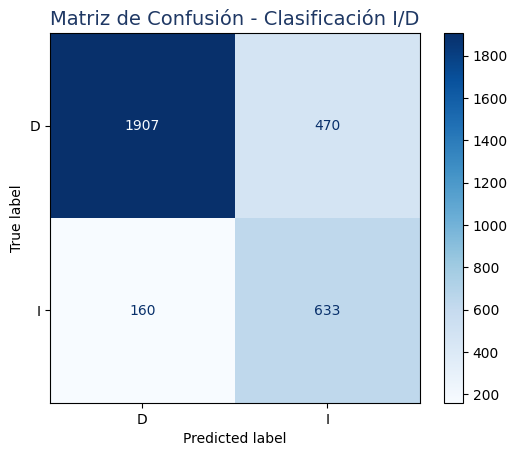

In [7]:
# TODO 4: métricas de clasificación + matriz de confusión
print("=== Métricas de Clasificación ===")
print(f"Exactitud (Accuracy):  {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precisión (Precision): {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"Recall:               {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"F1-Score:             {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"AUC-ROC:              {roc_auc_score(y_test_clf, y_proba_clf):.4f}")
print(f"AUC-PR:               {average_precision_score(y_test_clf, y_proba_clf):.4f}")
print()

# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["D", "I"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Clasificación I/D", fontsize=14, color=COLOR_TITULO)
plt.show()


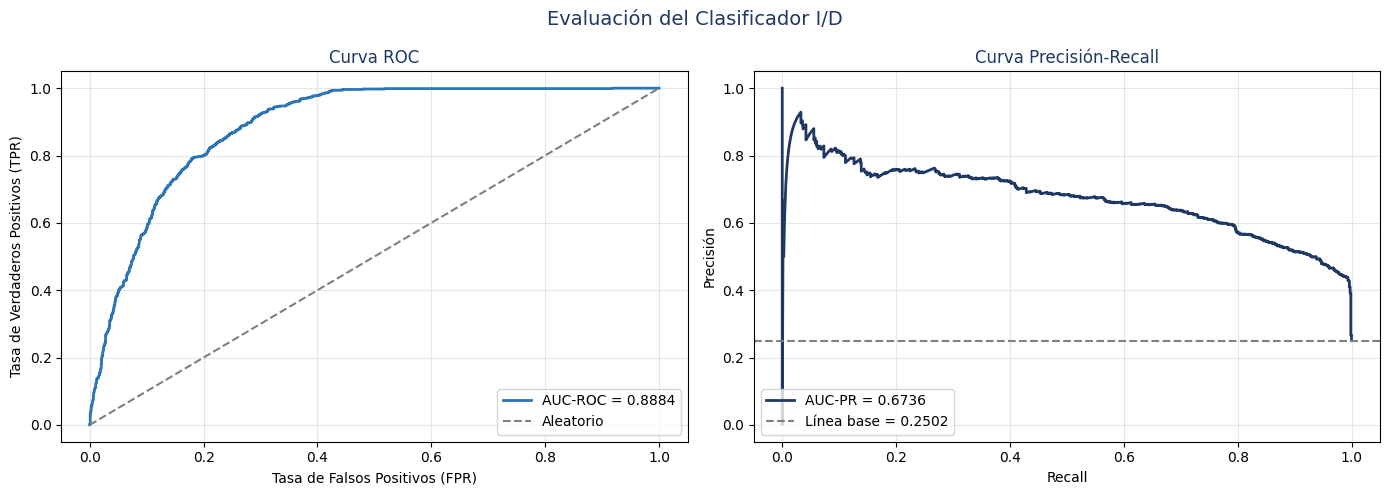

In [8]:
# TODO 5: curvas ROC y Precisión-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = roc_auc_score(y_test_clf, y_proba_clf)
ax1.plot(fpr, tpr, color="#2E75B6", lw=2, label=f"AUC-ROC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatorio")
ax1.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax1.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax1.set_title("Curva ROC", fontsize=12, color=COLOR_TITULO)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Curva Precisión-Recall
precision, recall, _ = precision_recall_curve(y_test_clf, y_proba_clf)
avg_prec = average_precision_score(y_test_clf, y_proba_clf)
base = y_test_clf.mean()
ax2.plot(recall, precision, color="#1F3864", lw=2, label=f"AUC-PR = {avg_prec:.4f}")
ax2.axhline(y=base, color="gray", linestyle="--", label=f"Línea base = {base:.4f}")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precisión")
ax2.set_title("Curva Precisión-Recall", fontsize=12, color=COLOR_TITULO)
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.suptitle("Evaluación del Clasificador I/D", fontsize=14, color=COLOR_TITULO)
plt.tight_layout()
plt.show()


<span style="color:#2E75B6;">**Análisis de resultados de clasificación:**</span>

- **Exactitud (Accuracy):** Mide el porcentaje global de aciertos. Sin embargo, debido al desbalance de clases (75% D, 25% I), un clasificador que siempre predijera "D" tendría un 75% de exactitud, lo que la convierte en una métrica engañosa.
- **Precisión y Recall:** Son más informativas. La precisión indica cuántas de nuestras predicciones "I" fueron correctas. El recall indica qué fracción de los "I" reales logramos capturar.
- **F1-Score:** Balance entre precisión y recall. Es una métrica robusta para datos desbalanceados.
- **AUC-ROC:** Mide la capacidad discriminativa del modelo (separar I de D) independientemente del umbral.
- **AUC-PR:** Más sensible al rendimiento en la clase minoritaria (I), recomendada para datos desbalanceados.


## **6. Fase 5: Modelado y Evaluación — Regresión**

<span style="color:#2E75B6;">**6.1 Regresor para cnt_operaciones:**</span> Se entrena un modelo de **Regresión Lineal** para estimar el volumen mensual de operaciones.

**Features:** `anio`, `mes`, `es_internacional`, `media_historica_aero` (media de operaciones por aeropuerto calculada solo en train para evitar fuga de datos)
**Target:** `cnt_operaciones`


In [9]:
# TODO 6: regresor
# 1) Dividir 80/20
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEMILLA)

# 2) Media histórica por aeropuerto (solo train)
media_aero_train = train_df.groupby("aeropuerto_oaci")["cnt_operaciones"].mean()
media_global_train = train_df["cnt_operaciones"].mean()

# 3) Mapear a train y test
train_df["media_historica_aero"] = train_df["aeropuerto_oaci"].map(media_aero_train)
test_df["media_historica_aero"] = test_df["aeropuerto_oaci"].map(media_aero_train)
test_df["media_historica_aero"] = test_df["media_historica_aero"].fillna(media_global_train)

# 4) Features y target
feature_cols = ["anio", "mes", "es_internacional", "media_historica_aero"]
X_train_reg = train_df[feature_cols]
y_train_reg = train_df["cnt_operaciones"]
X_test_reg = test_df[feature_cols]
y_test_reg = test_df["cnt_operaciones"]

# 5) Escalar (fit en train)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# 6) Entrenar Regresión Lineal
reg = LinearRegression()
reg.fit(X_train_reg_scaled, y_train_reg)

# 7) Predecir
y_pred_reg = reg.predict(X_test_reg_scaled)

print("Modelo de regresión entrenado exitosamente.")
print(f"Coeficientes: {dict(zip(feature_cols, reg.coef_))}")


Modelo de regresión entrenado exitosamente.
Coeficientes: {'anio': np.float64(58.383526645066), 'mes': np.float64(-5.490704437756563), 'es_internacional': np.float64(-280.91995818023395), 'media_historica_aero': np.float64(1066.2436002324434)}


=== Métricas de Regresión ===
MAE:        324.29
MSE:        302487.95
RMSE:       549.99
R²:         0.8007
R² Ajustado: 0.8005
MAPE:       317.91%



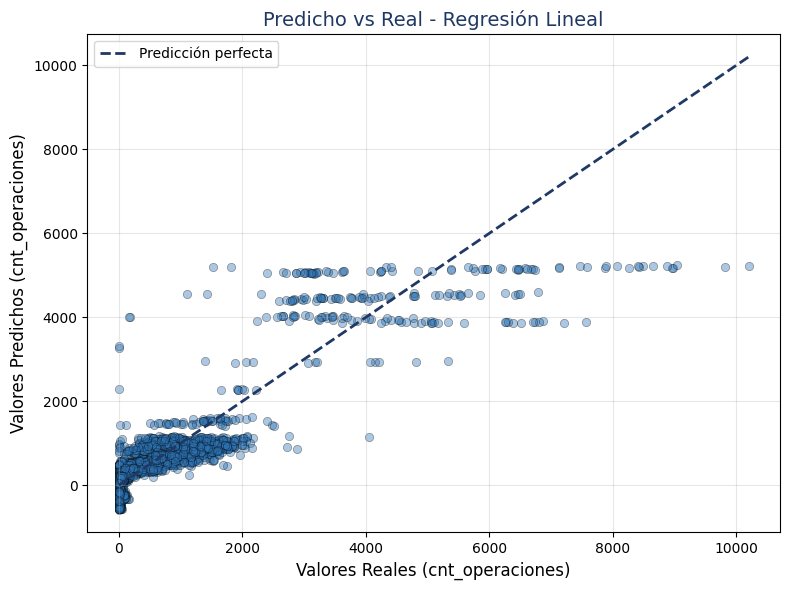

In [10]:
# TODO 7: métricas de regresión + gráfico predicho vs real
print("=== Métricas de Regresión ===")

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)
n = len(y_test_reg)
p = len(feature_cols)
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# MAPE (solo sobre valores >= 10)
mask_mape = y_test_reg >= 10
mape = (abs(y_test_reg[mask_mape] - y_pred_reg[mask_mape]) / y_test_reg[mask_mape]).mean() * 100

print(f"MAE:        {mae:.2f}")
print(f"MSE:        {mse:.2f}")
print(f"RMSE:       {rmse:.2f}")
print(f"R²:         {r2:.4f}")
print(f"R² Ajustado: {r2_adj:.4f}")
print(f"MAPE:       {mape:.2f}%")
print()

# Gráfico predicho vs real
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color="#2E75B6", edgecolors="black", linewidth=0.5)
plt.plot([0, y_test_reg.max()], [0, y_test_reg.max()], color="#1F3864", linestyle="--", lw=2, label="Predicción perfecta")
plt.xlabel("Valores Reales (cnt_operaciones)", fontsize=12)
plt.ylabel("Valores Predichos (cnt_operaciones)", fontsize=12)
plt.title("Predicho vs Real - Regresión Lineal", fontsize=14, color=COLOR_TITULO)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<span style="color:#2E75B6;">**Análisis de resultados de regresión:**</span>

- **MAE vs RMSE:** El RMSE es mayor que el MAE porque penaliza cuadráticamente los errores grandes. Si la diferencia entre ambos es considerable, indica presencia de outliers significativos en las predicciones.
- **R² y R² Ajustado:** El R² mide qué proporción de la variabilidad total es explicada por el modelo. El R² ajustado penaliza la inclusión de variables irrelevantes, permitiendo comparar modelos con distinto número de predictores.
- **MAPE:** Error porcentual absoluto medio. Se calcula solo sobre registros con `cnt_operaciones >= 10` porque para valores muy pequeños el MAPE se distorsiona (división por números cercanos a cero).

**Interpretación para el negocio:**
- El MAE es más intuitivo: "en promedio, nos equivocamos por X operaciones"
- El RMSE es más sensible a errores grandes: "cuando nos equivocamos, lo hacemos por Y operaciones en promedio cuadrático"
- Si los errores grandes ocurren en aeropuertos grandes (alta demanda), puede ser aceptable; si ocurren en aeropuertos pequeños, el impacto relativo es mayor.


---
## **7. Preguntas del Caso**

Responde cada pregunta basándote en el trabajo realizado en las fases anteriores.

---


**P1.** ¿Qué metodología estructura este caso y cuáles son sus seis fases? Nómbrala explícitamente.


>>> **RESPUESTA:** La metodología que estructura este caso es **CRISP-DM** (Cross-Industry Standard Process for Data Mining). Sus seis fases son:

1. **Entendimiento del Negocio** (Business Understanding) — Comprender los objetivos y requisitos del negocio.
2. **Entendimiento de los Datos** (Data Understanding) — Recopilar y explorar los datos disponibles.
3. **Preparación de los Datos** (Data Preparation) — Limpiar y transformar los datos para el modelado.
4. **Modelado** (Modeling) — Seleccionar y entrenar modelos de minería de datos.
5. **Evaluación** (Evaluation) — Evaluar si los modelos cumplen los objetivos del negocio.
6. **Despliegue** (Deployment) — Poner los modelos en producción para su uso operativo.


**P2.** Asocia tres actividades que realizaste en el notebook con la fase de CRISP-DM correspondiente.


>>> **RESPUESTA:**

| Actividad | Fase CRISP-DM |
|-----------|---------------|
| Definir objetivos de negocio (clasificar I/D, estimar cnt_operaciones) y traducirlos a objetivos de minería de datos | **Fase 1: Entendimiento del Negocio** |
| Cargar el dataset, explorar tipos de datos, distribución de clases y estadísticas descriptivas | **Fase 2: Entendimiento de los Datos** |
| Derivar variables predictoras (anio, mes, log_ops, es_internacional) y escalar features | **Fase 3: Preparación de los Datos** |
| Entrenar Regresión Logística y Regresión Lineal | **Fase 4: Modelado** |
| Calcular métricas (accuracy, precision, recall, F1, RMSE, R²) y graficar curvas ROC / PR | **Fase 5: Evaluación** |


**P3.** Enuncia el objetivo de negocio y explica cómo se traduce en los dos objetivos de minería de datos.


>>> **RESPUESTA:**

**Objetivo de negocio:** La DGAC/JAC necesita optimizar la asignación de recursos (control fronterizo, slots, personal especializado, planificación de infraestructura) según el tipo y volumen de tráfico aéreo en aeropuertos chilenos.

**Traducción a objetivos de minería de datos:**

1. **Clasificación:** Construir un modelo que prediga si un registro corresponde a tráfico internacional (I) o doméstico (D) usando variables como año, mes y cantidad de operaciones. Esto permite dimensionar recursos de control fronterizo y personal especializado.
2. **Regresión:** Construir un modelo que estime la cantidad de operaciones mensuales (`cnt_operaciones`) de un aeropuerto. Esto permite planificar infraestructura, turnos y capacidad operativa.


**P4.** ¿Qué variables predictoras derivaste y por qué cada una contribuye al objetivo de negocio?


>>> **RESPUESTA:** Las variables predictoras derivadas fueron:

1. **`anio`** (año): Captura la tendencia de largo plazo del tráfico aéreo. El volumen de operaciones ha crecido sostenidamente en las últimas décadas, con excepciones como la pandemia COVID-19. Esta variable ayuda al modelo a entender el contexto temporal.
2. **`mes`** (mes): Captura la estacionalidad anual. En Chile, los meses de verano (enero-febrero) tienen mayor tráfico aéreo, mientras que en invierno disminuye. Es crucial para estimar el volumen y el tipo de tráfico.
3. **`log_ops`** (logaritmo de operaciones): Normaliza la distribución asimétrica de `cnt_operaciones`. Al reducir el impacto de valores extremos (como SCEL con miles de operaciones), mejora el rendimiento de modelos lineales.
4. **`es_internacional`**: Variable binaria que indica si el tráfico es internacional. Los vuelos internacionales tienen diferentes patrones de frecuencia y volumen que los domésticos, por lo que es una predictora relevante para estimar `cnt_operaciones`.


**P5.** ¿Qué variable descartarías como predictora directa y por qué?


>>> **RESPUESTA:** Descartaría **`aeropuerto_oaci`** como predictora directa porque es una variable categórica con 69 valores distintos (los 69 aeropuertos). Al aplicar one-hot encoding, se generarían 68 columnas dummy, lo que aumenta la dimensionalidad innecesariamente y puede causar overfitting. En su lugar, se utiliza **`media_historica_aero`**, que condensa la información de cada aeropuerto en un solo valor numérico: el promedio histórico de operaciones de ese aeropuerto. Esta variable captura el "tamaño" y la "actividad típica" del aeropuerto de forma más eficiente.


**P6.** En la clasificación I/D, ¿qué representa un falso positivo y un falso negativo en el contexto aeroportuario? ¿Cuál es más costoso?


>>> **RESPUESTA:**

- **Falso Positivo (FP):** El modelo predice tráfico internacional (I) cuando en realidad es doméstico (D). Esto implicaría destinar recursos de control fronterizo y personal especializado a un vuelo que no los necesita, generando ineficiencia operativa.
- **Falso Negativo (FN):** El modelo predice tráfico doméstico (D) cuando en realidad es internacional (I). Esto implicaría no destinar los recursos necesarios a un vuelo internacional, pudiendo causar problemas aduaneros, migratorios y de seguridad.

**¿Cuál es más costoso?** El **falso negativo** es más costoso porque las consecuencias de no controlar adecuadamente un vuelo internacional (problemas migratorios, aduaneros, de seguridad) son más graves que asignar recursos de más a un vuelo doméstico. Por esta razón, el recall (sensibilidad para detectar la clase I) es particularmente importante.


**P7.** ¿Por qué la exactitud puede engañar en este dataset? ¿Qué métricas reportarías en su lugar?


>>> **RESPUESTA:**

La **exactitud (accuracy)** puede engañar porque el dataset está desbalanceado: aproximadamente el 75% de los registros son domésticos (D) y solo el 25% son internacionales (I). Un clasificador trivial que siempre predijera "D" tendría un 75% de exactitud sin aprender nada. Por lo tanto, una exactitud del 80% podría sonar bien pero enmascarar un rendimiento pobre en la clase minoritaria (I).

En su lugar, reportaría:
1. **Precisión** — ¿De las predicciones "I", cuántas son correctas?
2. **Recall** — ¿De los "I" reales, cuántos capturamos?
3. **F1-Score** — Balance armónico entre precisión y recall.
4. **AUC-ROC** — Capacidad discriminativa global del modelo.
5. **AUC-PR** — Más sensible al rendimiento en la clase minoritaria.

Estas métricas, en conjunto, ofrecen una visión más realista del desempeño del modelo en ambas clases.


**P8.** En la regresión del volumen, ¿por qué RMSE suele ser mayor que MAE y qué indica esa diferencia?


>>> **RESPUESTA:**

El **RMSE** (Root Mean Squared Error) suele ser mayor que el **MAE** (Mean Absolute Error) porque el RMSE eleva los errores al cuadrado antes de promediarlos, lo que penaliza más fuertemente los errores grandes. Por ejemplo, un error de 100 unidades contribuye como 10,000 al MSE, mientras que en el MAE contribuye como 100.

**¿Qué indica la diferencia?** Si RMSE es significativamente mayor que MAE, indica que existen **outliers o errores grandes** en las predicciones. En nuestro contexto, estos errores grandes probablemente corresponden a aeropuertos con volúmenes muy altos (como SCEL/Santiago) donde el modelo subestima o sobrestima significativamente. Para el negocio, el MAE es más intuitivo ("error promedio"), mientras que el RMSE alerta sobre la presencia de errores graves que requieren atención.


**P9.** ¿En qué situación NO conviene usar MAPE en este dataset?


>>> **RESPUESTA:**

No conviene usar **MAPE** (Mean Absolute Percentage Error) cuando el valor real de `cnt_operaciones` es muy pequeño (cercano a 0). El MAPE divide el error absoluto entre el valor real, por lo que si el valor real es, por ejemplo, 1 operación, una diferencia de 5 operaciones resulta en un error porcentual del 500%, distorsionando la métrica.

En este dataset, hay registros con `cnt_operaciones = 1` (especialmente en aeropuertos pequeños con tráfico doméstico muy reducido). Por esta razón, es recomendable filtrar los valores menores a 10 (como se hizo en el notebook) antes de calcular el MAPE, o alternativamente usar **MAE** o **RMSE** que no dependen de la escala relativa.


**P10.** ¿Cómo determina la fase de Evaluación de CRISP-DM si el modelo avanza a Despliegue?


>>> **RESPUESTA:**

La **Fase 5: Evaluación** de CRISP-DM compara los resultados del modelo contra los **objetivos de negocio** definidos en la Fase 1. Para determinar si el modelo avanza a Despliegue (Fase 6), se evalúan:

1. **Cumplimiento de KPIs:** ¿El modelo alcanzó las métricas objetivo? Por ejemplo, si definimos precisión ≥ 0.80 y el modelo obtuvo 0.85, cumple el criterio.
2. **Revisión del proceso:** ¿Se siguieron correctamente todas las fases? ¿Hay sesgos o errores metodológicos?
3. **Validación con stakeholders:** ¿Los resultados son aceptables para los usuarios del negocio (DGAC/JAC)? ¿Las predicciones tienen sentido operativo?
4. **Análisis de costo-beneficio:** ¿El beneficio de usar el modelo supera el costo de implementación y mantenimiento?

Si el modelo cumple todos los criterios, avanza a Despliegue. Si no, se retrocede a fases anteriores para mejorar el modelo (por ejemplo, seleccionar mejores features, probar otros algoritmos, o recopilar más datos).


---
## **8. Referencias (APA 7)**

- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.
- Han, J., Pei, J., & Tong, H. (2022). *Data mining: Concepts and techniques* (4.ª ed.). Morgan Kaufmann.
- Spiegel, M. R., & Stephens, L. J. (2009). *Estadística* (4.ª ed., Serie Schaum). McGraw-Hill.

---

*Nota: Este notebook fue desarrollado por Benjamin Herrera como caso de estudio de la asignatura BIY7121 - Minería de Datos.*
